# Imports

In [1]:
import pandas as pd
import numpy as np
import pickle as pk
import os
import seaborn as sns
import matplotlib.pyplot as plt
import json
from brokenaxes import brokenaxes
from sklearn.manifold import TSNE
from tqdm import tqdm
import scipy
import statsmodels.api as sm
import torch
from sklearn.metrics import cohen_kappa_score
import io
pd.set_option('display.max_columns', None)
pd.set_option('future.no_silent_downcasting', True)
plt.rcParams.update({
    "axes.facecolor": "white",                      
    "axes.edgecolor": "black",                      
    "patch.facecolor": "lightcoral",
    "text.usetex": False,                           
    "font.family": "sans-serif",                    
    "axes.spines.top": False,                       
    "axes.spines.right": False,                     
    "axes.labelsize": 16,                           
    "xtick.labelsize": 14,                          
    "ytick.labelsize": 14,                          
    "axes.titlesize": 18,                           
    "figure.dpi": 300,                              
})

# Globals

In [2]:
num_features = 138
base_path = "../../"
os.makedirs(base_path + "plots/Supplementary/FigureS1/", exist_ok=True)

# Load Data

In [3]:
data = pd.read_csv(base_path + "csvs/hills.csv")
data = data[~data["response"].isin(["mammal", "bacterium", "unicorn", "woollymammoth"])].reset_index(drop=True)
data["previous_response"] = data.groupby("pid")["response"].shift(1)
data["order"] = data.groupby("pid").cumcount() + 1
data = data.drop(columns=["fpatchnum", "fpatchitem", "fitemsfromend", "flastitem",  "meanirt", "catitem"])

# Load Learnt Weights

In [4]:
try:
    with open(base_path + "fits/model_fits/freqweightedhsactivity_fits_gpt41_fulldata_cpu.pk", "rb") as f:
        results = pk.load(f)
except:
    _original_load_from_bytes = torch.storage._load_from_bytes  # Force CUDA tensors inside pickle to load on CPU
    def _load_from_bytes_cpu(b):
        return torch.load(io.BytesIO(b), map_location=torch.device("cpu"))
    torch.storage._load_from_bytes = _load_from_bytes_cpu
    with open(base_path + "fits/model_fits/freqweightedhsactivity_fits_gpt41_fulldata.pk", "rb") as f:       # Load old CUDA-saved pickle
        results = pk.load(f)
    torch.storage._load_from_bytes = _original_load_from_bytes  # Restore original behavior
    with open(base_path + "fits/model_fits/freqweightedhsactivity_fits_gpt41_fulldata_cpu.pk", "wb") as f:   # Re-save CPU-compatible pickle
        pk.dump(results, f)
    with open(base_path + "fits/model_fits/freqweightedhsactivity_fits_gpt41_fulldata_cpu.pk", "rb") as f:
        results = pk.load(f)

learned_weights = results["weights_fold1_fulldata"].numpy()
learned_freq_weight = learned_weights[0]
learned_HS_weights = learned_weights[1:1+num_features]
learned_Act_weights = learned_weights[1+num_features:]

# Get features

In [5]:
def get_featuredf(llm_name):
    featuredict = pk.load(open(base_path + f"files/features_{llm_name}.pk", "rb"))
    featuredf = pd.DataFrame.from_dict(featuredict, orient='index')
    featuredf = featuredf.replace({True: 1, False: 0, 'True': 1, 'True.': 1, 'TRUE': 1, 'true': 1, 'true.': 1, 'True.': 1, 'False': 0, 'False.': 0, 'false': 0, 'false.': 0, 'False.': 0})
    featuredf = featuredf[featuredf.applymap(lambda x: isinstance(x, int)).all(axis=1)]
    return featuredf.astype(int), featuredf.columns.tolist()

vf_featuredf, vf_featurecols = get_featuredf("gpt41")
vf_featuredf = vf_featuredf.loc[vf_featuredf.index.isin(data["response"])]

/tmp/ipykernel_897062/1080171364.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  featuredf = featuredf[featuredf.applymap(lambda x: isinstance(x, int)).all(axis=1)]


# Add features to responses

In [6]:
def add_features_to_responsedf(df):
    featuredict = vf_featuredf.to_dict(orient='index')
    mapped_features = df['response'].map(featuredict)
    mapped_features = mapped_features.apply(lambda x: x if isinstance(x, dict) else {})
    fc = pd.DataFrame(mapped_features.tolist())
    df = pd.concat([df, fc], axis=1)
    df = df.replace({'True': 1, 'True.': 1, 'False': 0, 'False.': 0})
    dropped_rows = df[df[vf_featurecols].isna().any(axis=1)]
    df = df.dropna(subset=vf_featurecols)
    for col in vf_featurecols:
        df[col] = df[col].astype(int)
    return df, dropped_rows

data, dropped_rows = add_features_to_responsedf(data)
feature_cols = [col for col in data.columns if col.startswith('feature_')]

# Figure S1: Replication of Figure 2 using weighted measures

In [7]:
datacopy = data.copy()

## Figure S1A

In [8]:
def get_wHS(df, featurecols):
    df['wHS'] = None
    df = df.groupby('pid', group_keys=False).apply(calculate_wHS, featurecols = featurecols)
    return df

def calculate_wHS(group, featurecols):
    group = group.reset_index(drop=True)
    wHS = [np.nan]  # Initialize with nan for the first row
    
    for i in range(1, len(group)):
        row1 = group.loc[i - 1, featurecols]
        row2 = group.loc[i, featurecols]
        
        # Check for NaN values
        if row1.isna().any() or row2.isna().any():
            wHS.append(np.nan)
        else:
            consecutive_1s = ((row1 == 1) & (row2 == 1)) | ((row1 == 0) & (row2 == 0))
            wHS.append(np.dot(consecutive_1s.astype(float).values, learned_HS_weights))
    
    group['wHS'] = wHS
    return group

data = get_wHS(data, vf_featurecols)

/tmp/ipykernel_897062/2524539466.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['wHS'] = None
/tmp/ipykernel_897062/2524539466.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('pid', group_keys=False).apply(calculate_wHS, featurecols = featurecols)


In [9]:
data = data.dropna()

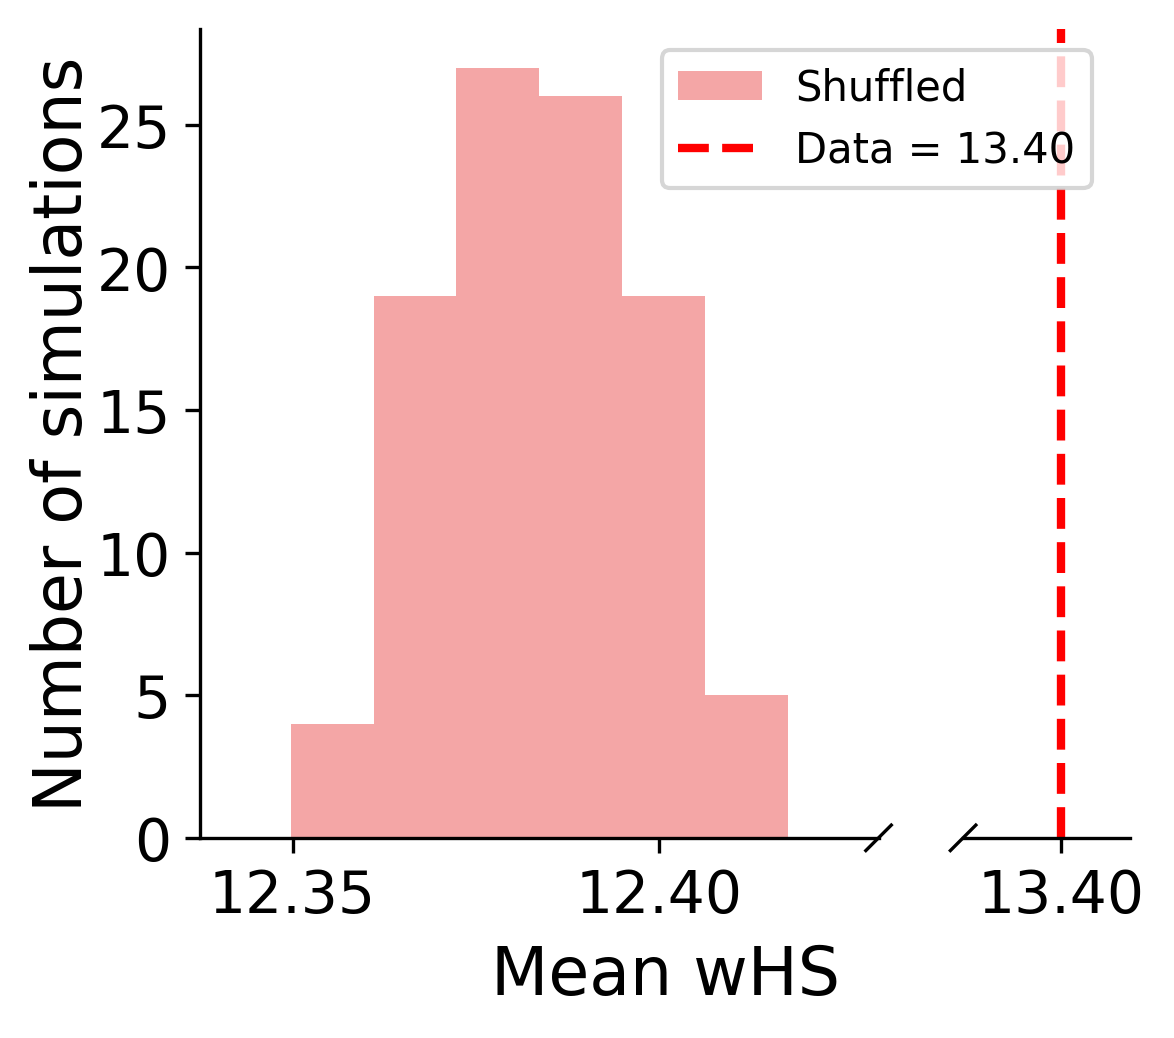

In [10]:
# shuffle within each pid - TAKES SUPER LONG, SERIALIZE
try:
    means = pk.load(open(base_path + "files/shuffled_data_meanwHS.pk", "rb"))
except:
    means = []
    for _ in tqdm(range(100)):
        shuffled_data2 = data.groupby("pid", group_keys=False).apply(lambda x: x.sample(frac=1).reset_index(drop=True))
        shuffled_data2 = get_wHS(shuffled_data2, vf_featurecols)
        means.append(np.mean(shuffled_data2[["wHS", "pid"]].groupby("pid").mean()["wHS"].values))
    pk.dump(means, open(base_path + "files/shuffled_data_meanwHS.pk", "wb"))

plt.rcParams['figure.dpi'] = 300
plt.figure(figsize=(4, 3.5))
data_mean = round(np.mean(data[["wHS", "pid"]].groupby("pid").mean()["wHS"].values), 1)
bax = brokenaxes(xlims=((min(means)-0.001*min(means), max(means)+0.001*min(means)), (data_mean - 0.001*data_mean, data_mean + 0.0007*data_mean)),hspace=0.05)
bax.hist(means, bins=6, color='lightcoral', label="Shuffled", alpha=0.7)
bax.axvline(data_mean, color='red', linestyle='--', linewidth=2, label=f'Data = {data_mean:.2f}')
bax.set_xlabel("Mean wHS", labelpad=25)
bax.set_ylabel("Number of simulations", labelpad=25)
# bax.axs[0].set_xticks([98.0, 98.5])
# bax.axs[1].set_xticks([105, 106])
bax.legend(loc='upper right', bbox_to_anchor=(0.981, 1))
plt.savefig(base_path + "plots/Supplementary/FigureS1/S1A.pdf", bbox_inches='tight')
plt.show()

## Figure S1B

In [11]:
def get_wHS(df, featurecols, nback):
    df[f'wHS_{nback}back'] = np.nan  # Initialize the column with NaN
    df = df.groupby('pid', group_keys=False).apply(calculate_wHS, featurecols=featurecols, nback=nback)
    return df

def calculate_wHS(group, featurecols, nback):
    group = group.reset_index(drop=True)
    
    wHS = np.full(len(group), np.nan)  # Initialize with NaN
    
    for i in range(nback, len(group)):
        row1 = group.loc[i - nback, featurecols]
        row2 = group.loc[i, featurecols]

        # Check for NaN values
        if row1.isna().any() or row2.isna().any():
            wHS[i] = np.nan
        else:
            consecutive_1s = ((row1 == 1) & (row2 == 1)) | ((row1 == 0) & (row2 == 0))
            wHS[i] = np.dot(consecutive_1s.astype(float).values, learned_HS_weights)
    
    group[f'wHS_{nback}back'] = wHS  # Assign correctly
    return group

data = get_wHS(data, vf_featurecols, 2)
data = get_wHS(data, vf_featurecols, 3)
data = get_wHS(data, vf_featurecols, 4)
data = get_wHS(data, vf_featurecols, 5)

/tmp/ipykernel_897062/1738705401.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('pid', group_keys=False).apply(calculate_wHS, featurecols=featurecols, nback=nback)
/tmp/ipykernel_897062/1738705401.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('pid', group_keys=False).apply(calculate_wHS, featurecols=featurecols, nback=nback)
/tmp/ipykernel_897062/1738705401.py:3: D

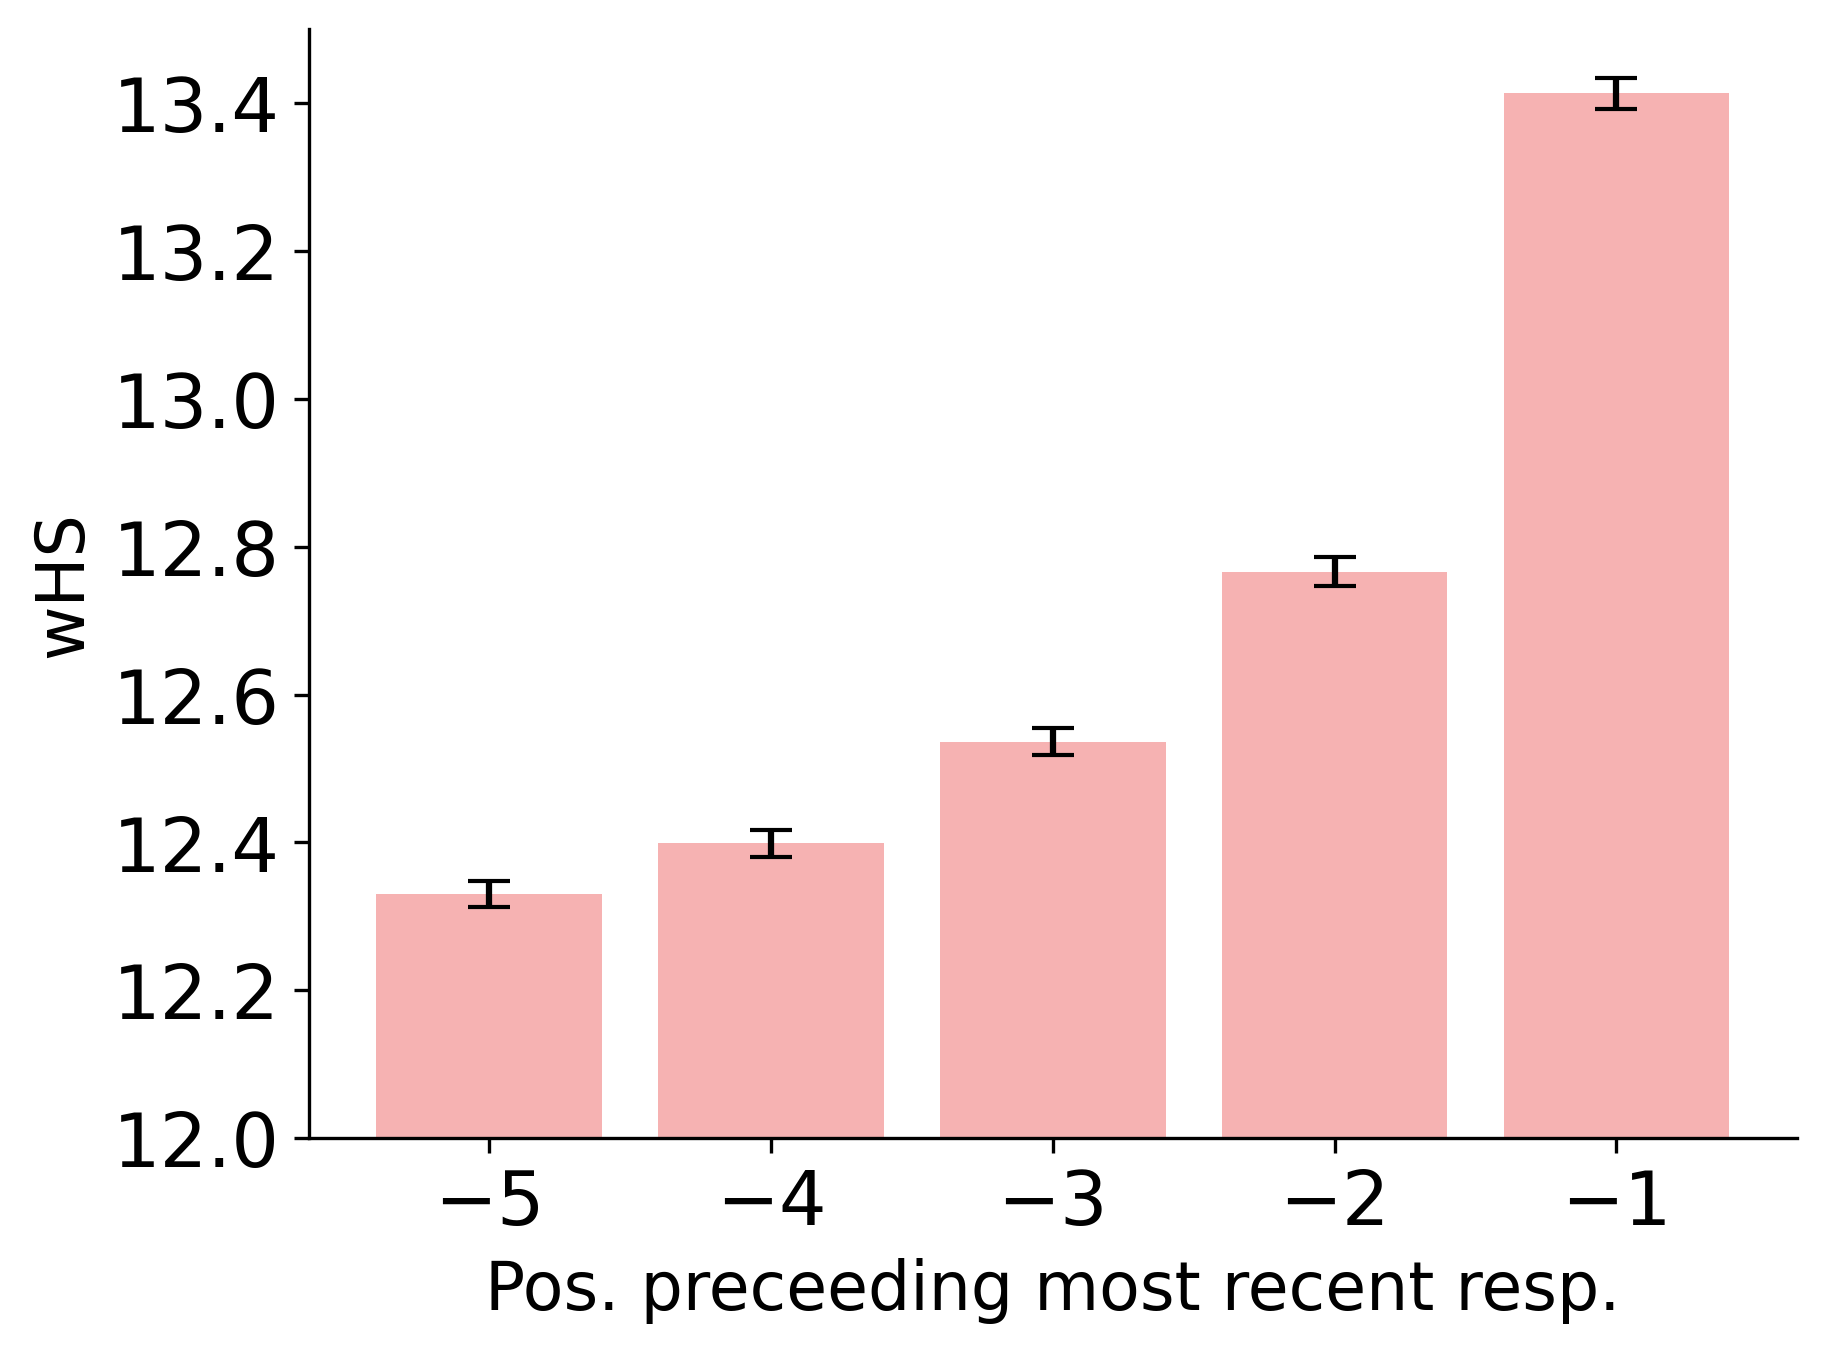

In [12]:
# Calculate means and standard errors
means = [
    np.mean(data["wHS_5back"]),
    np.mean(data["wHS_4back"]),
    np.mean(data["wHS_3back"]),
    np.mean(data["wHS_2back"]),
    np.mean(data["wHS"])
]

std_errors = [
    np.std(data["wHS_5back"], ddof=1) / np.sqrt(len(data["wHS_5back"].dropna())),
    np.std(data["wHS_4back"], ddof=1) / np.sqrt(len(data["wHS_4back"].dropna())),
    np.std(data["wHS_3back"], ddof=1) / np.sqrt(len(data["wHS_3back"].dropna())),
    np.std(data["wHS_2back"], ddof=1) / np.sqrt(len(data["wHS_2back"].dropna())),
    np.std(data["wHS"], ddof=1) / np.sqrt(len(data["wHS"].dropna()))
]

x_labels = [-5, -4, -3, -2, -1]

plt.bar(x_labels, means, yerr=std_errors, capsize=5, alpha=0.6, color='lightcoral')
plt.xlabel("Pos. preceeding most recent resp.")
plt.ylabel("wHS")
plt.ylim(12, 13.5)
plt.xticks(x_labels, fontsize=18)
plt.yticks(fontsize=18)
plt.savefig(base_path + "plots/Supplementary/FigureS1/S1B.pdf", bbox_inches="tight")

## Figure S1C

In [13]:
data["sum_features"] = data[vf_featurecols].sum(axis=1)
data["logRT"] = np.log(data["RT"] + 0.001)
data = data[data["logRT"] > -1.6]   # removes RT < 200 ms

/tmp/ipykernel_897062/2731495189.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = data.groupby("bin2")["logRT"].agg(['mean', 'sem']).reset_index()


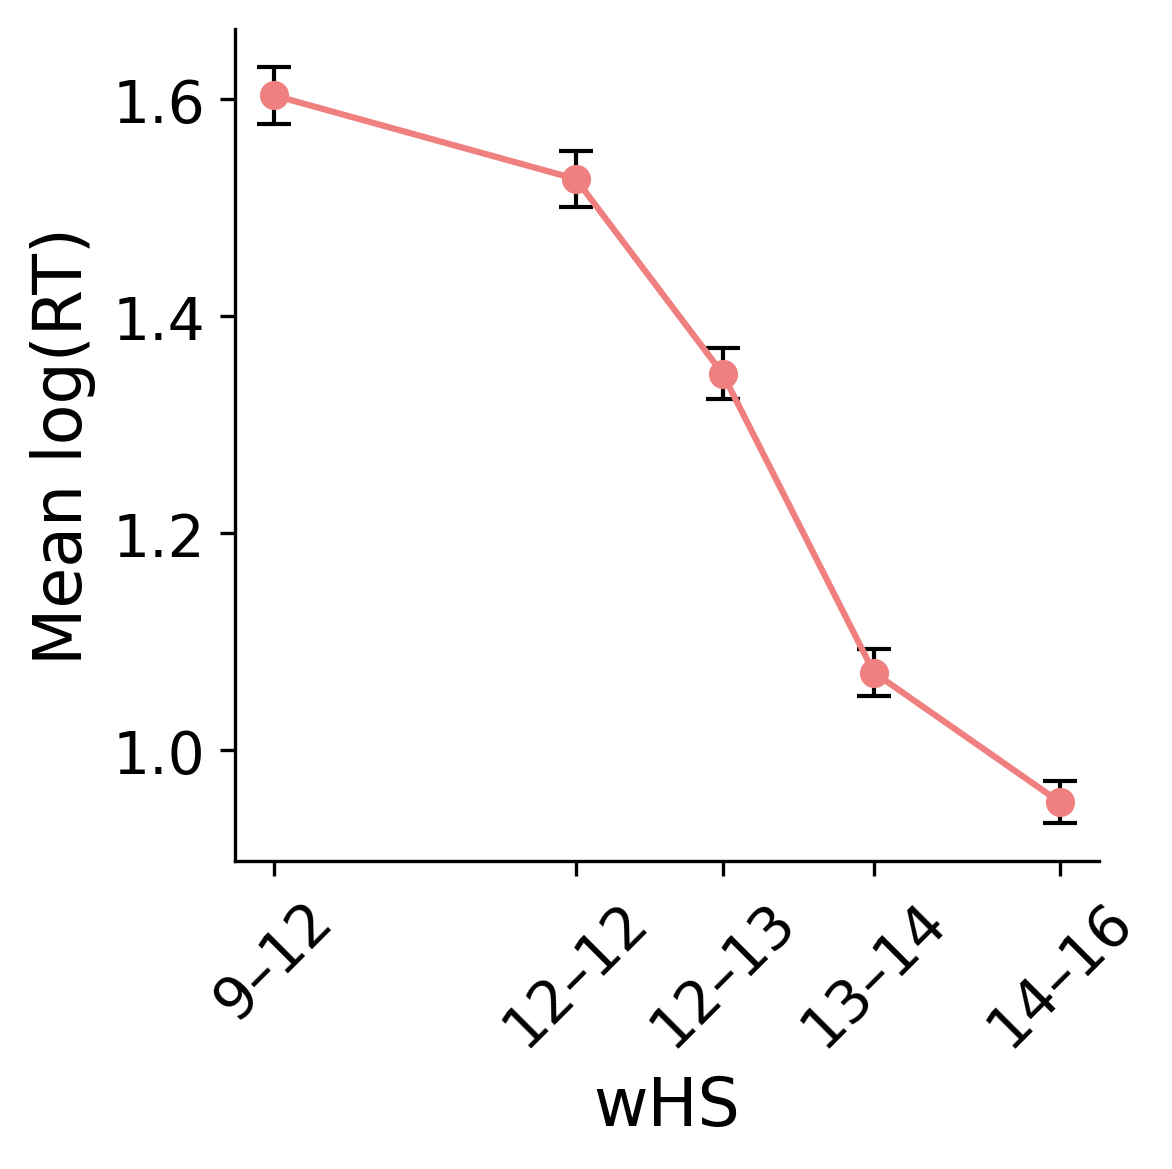

In [14]:
data["bin2"] = pd.qcut(data["wHS"], q=5)
group_stats = data.groupby("bin2")["logRT"].agg(['mean', 'sem']).reset_index()
x_positions = [ (interval.left + interval.right) / 2 for interval in group_stats["bin2"] ]
bin_labels = [f"{int(interval.left)}–{int(interval.right)}" for interval in group_stats["bin2"]]
plt.figure(figsize=(4, 4))
plt.errorbar(
    x_positions,
    group_stats["mean"],
    yerr=group_stats["sem"],
    fmt='o-',
    color='lightcoral',
    ecolor='black',
    elinewidth=1,
    capsize=4
)
plt.xticks(ticks=x_positions, labels=bin_labels, rotation=45)
plt.xlabel("wHS")
plt.ylabel("Mean log(RT)")
plt.tight_layout()
plt.savefig(base_path + "plots/Supplementary/FigureS1/S1C.pdf")
plt.show();

## Figure S1D

In [15]:
data = datacopy

In [16]:
num_simulations = 100

# Uniform
sum_weighted_activity_diff1 = []
pid_to_count = data.groupby("pid")["response"].count().to_dict()
unique_responses = data["response"].unique()
for i in range(num_simulations):
    data_simulatedrandom = pd.DataFrame(columns=["pid", "response"])
    for pid, count in pid_to_count.items():
        sampled_responses = np.random.choice(unique_responses, size=count, replace=False)
        temp_df = pd.DataFrame({
            "pid": [pid] * count,
            "response": sampled_responses
        })
        data_simulatedrandom = pd.concat([data_simulatedrandom, temp_df], ignore_index=True)
    data_simulatedrandom, dropped_rows2_simulatedrandom = add_features_to_responsedf(data_simulatedrandom)
    mean_wAct = data_simulatedrandom.assign(wAct=data_simulatedrandom[feature_cols].values @ learned_Act_weights).groupby("pid")["wAct"].mean().mean()
    sum_weighted_activity_diff1.append(mean_wAct)

In [17]:
# Frequency-based
with open(base_path + "files/freq_abs_log.json", "r") as f:
    freq_abs = json.load(f)
freq_abs = {k: v for k, v in freq_abs.items() if k.replace(" ", "").replace("-", "") in unique_responses}
with open(base_path + "files/response_corrections.json", 'r') as f:
    corrections = json.load(f)
probs = np.array([freq_abs[corrections.get(r, r)] for r in unique_responses])
probs = np.exp(probs)          # convert from log frequencies
probs /= probs.sum()           # normalize to sum to 1
sum_weighted_activity_diff2 = []
for i in range(num_simulations):
    data_simulatedrandom = pd.DataFrame(columns=["pid", "response"])
    for pid, count in pid_to_count.items():
        sampled_responses = np.random.choice(unique_responses, size=count, replace=False, p=probs)
        temp_df = pd.DataFrame({
            "pid": [pid] * count,
            "response": sampled_responses
        })
        data_simulatedrandom = pd.concat([data_simulatedrandom, temp_df], ignore_index=True)
    data_simulatedrandom, dropped_rows2_simulatedrandom = add_features_to_responsedf(data_simulatedrandom)
    mean_wAct = data_simulatedrandom.assign(wAct=data_simulatedrandom[feature_cols].values @ learned_Act_weights).groupby("pid")["wAct"].mean().mean()
    sum_weighted_activity_diff2.append(mean_wAct)

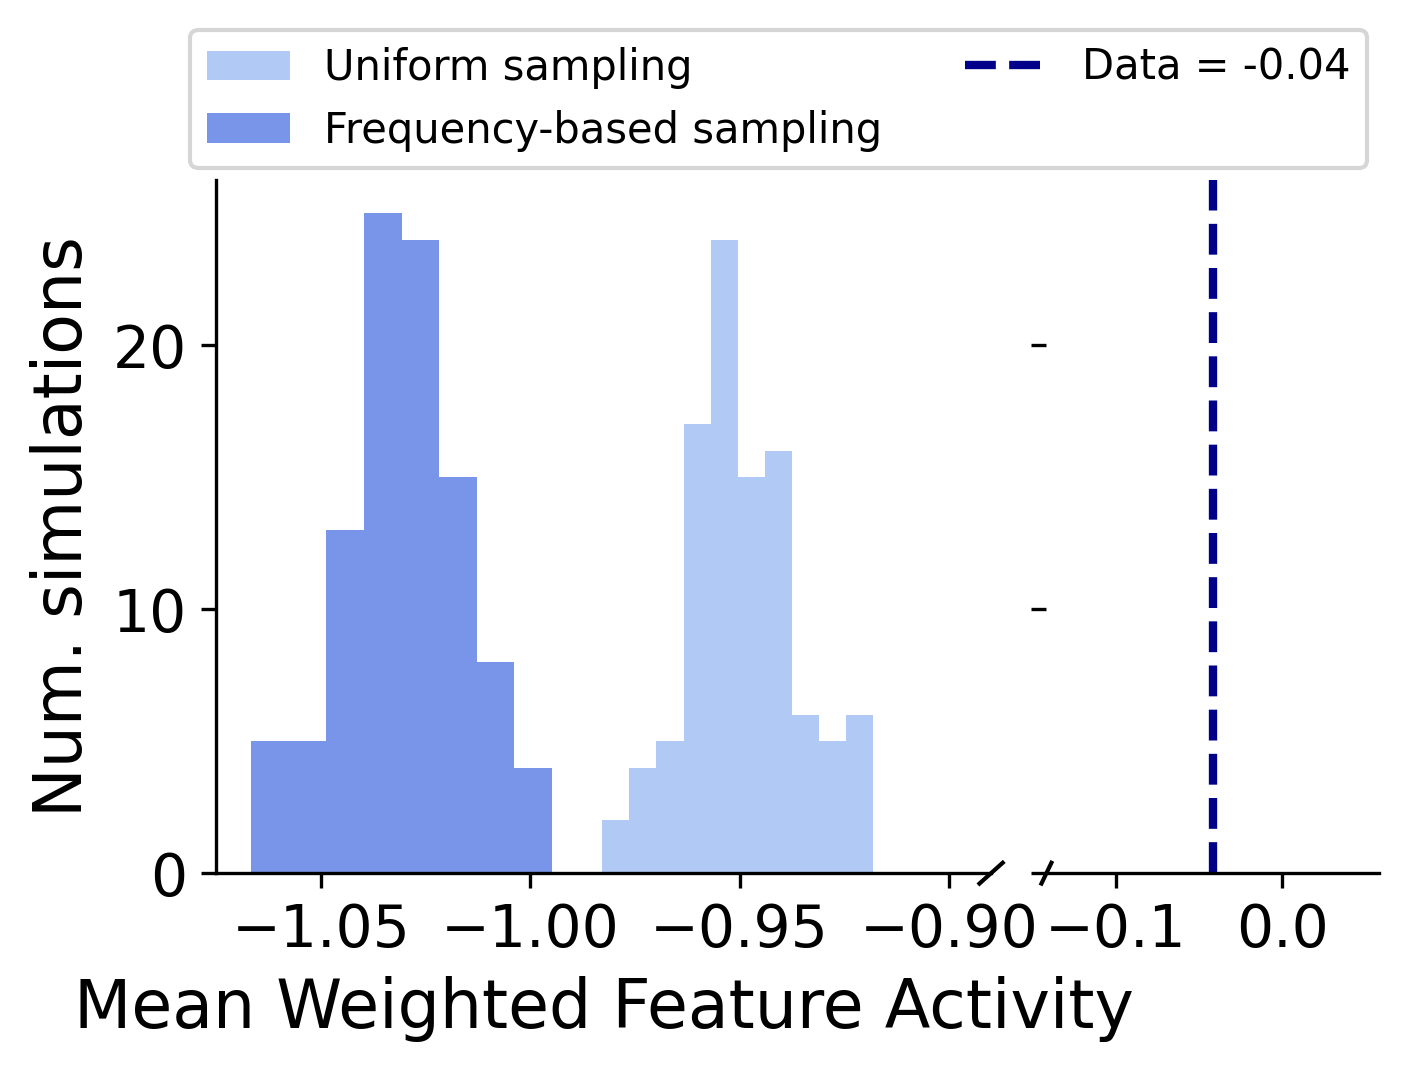

In [18]:
# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(5,3), gridspec_kw={'width_ratios': [0.7,0.3], 'wspace': 0.1})
ax1.hist(sum_weighted_activity_diff1, alpha=0.5, label='Uniform sampling', color='cornflowerblue')
ax1.set_ylabel("Num. simulations")
ax1.set_xlim(-1.075, -0.89)
ax1.hist(sum_weighted_activity_diff2, alpha=0.7, label='Frequency-based sampling', color='royalblue')
ax1.set_xlabel("Mean Weighted Feature Activity")
vline_value = data.assign(wAct=data[feature_cols].values @ learned_Act_weights).groupby("pid")["wAct"].mean().mean()
ax2.axvline(vline_value, color='darkblue', linestyle='--', linewidth=2, label=f'Data = {vline_value:.2f}')
ax2.set_xlim(vline_value - 0.1, vline_value + 0.1)

ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

d = 0.015  # smaller break marker
def add_break(ax_left, ax_right):
    kwargs = dict(color='k', clip_on=False, linewidth=1)
    ax_left.plot((1 - d, 1 + d), (-d, +d), transform=ax_left.transAxes, **kwargs)
    ax_right.plot((-d, +d), (-d, +d), transform=ax_right.transAxes, **kwargs)

add_break(ax1, ax2)
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.07), ncol=2)
plt.savefig(base_path + "plots/Supplementary/FigureS1/S1D.pdf", bbox_inches="tight")